# From Long to Wide: Reshaping Healthcare Claims Data

**Python for Data Science II - Healthcare Analytics**

---

## Why this matters

The dataset you were given is a **claims line-item extract**. That is the shape claims data almost always arrives in from a payer or a hospital billing system, because that is how it is *generated* - one row every time something is billed.

But it is rarely the shape you need to *analyse*. Most analytical questions - What does a cardiac admission actually cost? Which hospital is expensive for which condition? Can I cluster patients by their spending profile? - are questions about **entities** (a claim, a member, a hospital), not about billing lines.

Reshaping long to wide is how you move from *how the data was recorded* to *how the question is asked*.

## What you will learn

1. How to **prove** a dataset is in long format instead of guessing
2. `pivot` vs `pivot_table` - and why the first one will fail here
3. What a `NaN` means after a pivot (hint: it is not missing data)
4. **Validating** a reshape - never trust a pivot you have not reconciled
5. Operations that are natural in wide format: row-normalisation, correlation, composition
6. Visualisations that only make sense on a wide frame: stacked composition bars, heatmaps
7. `melt` - the inverse operation, and why the round trip is not perfectly lossless

---

## 0. Setup

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda v: f'{v:,.1f}')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('pandas', pd.__version__)

pandas 2.3.3


In [48]:
URL = ('https://raw.githubusercontent.com/thousandoaks/Python4DS-I/'
       'main/datasets/HealthcareDataset_PublicRelease.csv')

claims = pd.read_csv(URL, parse_dates=['StartDate', 'EndDate', 'BirthDate'])

print(f'{claims.shape[0]:,} rows x {claims.shape[1]} columns')
claims.head()

52,563 rows x 17 columns


,Id,MemberName,MemberID,County,MedicalClaim,ClaimItem,HospitalName,HospitalType,StartDate,EndDate,PrincipalDiagnosisDesc,PrincipalDiagnosis,RevenueCodeDesc,RevenueCode,TypeFlag,BirthDate,TotalExpenses
0,634363,e659f3f4,6a380a28,6f943458,c1e3436737c77899,18,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.0,ER,1967-05-13,15.1
1,634364,e659f3f4,6a380a28,6f943458,c1e3436737c77899,21,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.0,ER,1967-05-13,3.1
2,634387,e659f3f4,6a380a28,6f943458,c1e3436737c77899,10,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,LABORATORY - CLINICAL DIAGNOSTIC: HEMATOLOGY,305.0,ER,1967-05-13,123.9
3,634388,e659f3f4,6a380a28,6f943458,c1e3436737c77899,20,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.0,ER,1967-05-13,7.5
4,634389,e659f3f4,6a380a28,6f943458,c1e3436737c77899,19,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.0,ER,1967-05-13,8.6


In [49]:
claims.dtypes.to_frame('dtype')

,dtype
Id,int64
MemberName,object
MemberID,object
County,object
MedicalClaim,object
ClaimItem,int64
HospitalName,object
HospitalType,object
StartDate,datetime64[ns]
EndDate,datetime64[ns]


---

## 1. Is this long or wide? Prove it, do not eyeball it

Students usually guess by looking at the head of the frame. That works here, but it does not scale and it does not teach anything. Let us establish a **test** instead.

### The definition

- **Wide format**: one row per entity. Each measured variable gets its own column.
- **Long format**: one row per entity-*and*-variable pair. There is a *key* column naming the variable and a *value* column holding the measurement. Entity attributes are repeated on every row.

### The diagnostic

If the data is long, then **grouping by the entity ID will show that most columns are constant within a group**. Only the key column and the value column will vary. That redundancy is the fingerprint of long format.

First, what is the entity here?

In [50]:
n_rows     = len(claims)
n_ids      = claims['Id'].nunique()
n_claims   = claims['MedicalClaim'].nunique()
n_members  = claims['MemberID'].nunique()
n_hospital = claims['HospitalName'].nunique()

print(f'rows ................. {n_rows:,}')
print(f'unique Id ............ {n_ids:,}   <- one per row, so Id is the line-item key')
print(f'unique MedicalClaim .. {n_claims:,}')
print(f'unique MemberID ...... {n_members:,}')
print(f'unique HospitalName .. {n_hospital:,}')
print()
print(f'average rows per claim: {n_rows / n_claims:,.1f}')

rows ................. 52,563
unique Id ............ 52,563   <- one per row, so Id is the line-item key
unique MedicalClaim .. 3,361
unique MemberID ...... 1,757
unique HospitalName .. 148

average rows per claim: 15.6


There are several rows per claim. So a row is **not** a claim - it is a *line item within* a claim. `ClaimItem` is the line number.

Now the redundancy test. For each column, how many distinct values does it take **within a single claim**?

In [51]:
variation = (claims
             .groupby('MedicalClaim')
             .nunique()
             .max()
             .sort_values()
             .to_frame('max distinct values within one claim'))

variation['interpretation'] = np.where(
    variation.iloc[:, 0] == 1,
    'CONSTANT  -> claim-level attribute (redundantly repeated)',
    'VARIES    -> line-level: this is key or value')

variation

,max distinct values within one claim,interpretation
MemberName,1,CONSTANT -> claim-level attribute (redundantl...
MemberID,1,CONSTANT -> claim-level attribute (redundantl...
County,1,CONSTANT -> claim-level attribute (redundantl...
HospitalName,1,CONSTANT -> claim-level attribute (redundantl...
HospitalType,1,CONSTANT -> claim-level attribute (redundantl...
StartDate,1,CONSTANT -> claim-level attribute (redundantl...
EndDate,1,CONSTANT -> claim-level attribute (redundantl...
PrincipalDiagnosisDesc,1,CONSTANT -> claim-level attribute (redundantl...
PrincipalDiagnosis,1,CONSTANT -> claim-level attribute (redundantl...
TypeFlag,1,CONSTANT -> claim-level attribute (redundantl...


### Read the result carefully

Everything describing *the patient and the episode* - `MemberID`, `BirthDate`, `County`, `HospitalName`, `StartDate`, `EndDate`, `PrincipalDiagnosis` - is **constant within a claim** and therefore repeated on every line. That is pure redundancy: a 6-day cardiac admission with 18 billed lines stores the patient's birth date 18 times.

Only four things vary: `Id` (the row key), `ClaimItem` (the line number), `RevenueCode`/`RevenueCodeDesc` (**the variable being measured**), and `TotalExpenses` (**the value**).

> **This is the textbook long-format signature.**
> - Entity = `MedicalClaim`
> - Key / variable column = `RevenueCodeDesc`
> - Value column = `TotalExpenses`
> - Everything else = repeated entity attributes

In wide format, `RevenueCodeDesc` would not exist as a column of data. Its *values* would have become the column names.

Let us look at a single claim to make it concrete.

In [52]:
example_claim = claims['MedicalClaim'].value_counts().index[0]

(claims[claims['MedicalClaim'] == example_claim]
 [['MedicalClaim', 'ClaimItem', 'PrincipalDiagnosisDesc', 'TypeFlag',
   'RevenueCodeDesc', 'RevenueCode', 'TotalExpenses']]
 .sort_values('ClaimItem'))

,MedicalClaim,ClaimItem,PrincipalDiagnosisDesc,TypeFlag,RevenueCodeDesc,RevenueCode,TotalExpenses
16202,764580ebeaabfc68,1,Other specified fracture,ER,PHARMACY,250.0,92.3
16203,764580ebeaabfc68,2,Other specified fracture,ER,PHARMACY,250.0,92.3
16336,764580ebeaabfc68,3,Other specified fracture,ER,PHARMACY,250.0,92.3
16204,764580ebeaabfc68,4,Other specified fracture,ER,PHARMACY,250.0,46.2
16136,764580ebeaabfc68,5,Other specified fracture,ER,PHARMACY,250.0,46.2
...,...,...,...,...,...,...,...
16143,764580ebeaabfc68,123,Other specified fracture,ER,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.0,36.5
16326,764580ebeaabfc68,124,Other specified fracture,ER,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.0,30.1
16252,764580ebeaabfc68,125,Other specified fracture,ER,EKG/ECG,730.0,430.2
16253,764580ebeaabfc68,126,Other specified fracture,ER,TREATMENT/OBSERVATION ROOM: OBSERVATION ROOM,762.0,"12,363.6"


---

## 2. Prepare the columns you will pivot on

Two things need doing before we reshape.

### 2a. Collapse revenue codes into categories

`RevenueCodeDesc` follows the UB-04 convention `CATEGORY: subcategory`, e.g. `LABORATORY - CLINICAL DIAGNOSTIC: HEMATOLOGY`. If we pivot on the raw description we get dozens of near-empty columns. Splitting on the colon gives us a coarser, far more usable service category.

This is a general lesson: **the granularity of your key column becomes the width of your result.** Choose it deliberately.

### 2b. Derive claim-level features

Length of stay and age at admission are not in the file, but both are trivially derivable and both will be useful later.

In [53]:
claims['ServiceCategory'] = (claims['RevenueCodeDesc']
                             .str.split(':').str[0]
                             .str.strip())

claims['LengthOfStay'] = (claims['EndDate'] - claims['StartDate']).dt.days

age = (claims['StartDate'] - claims['BirthDate']).dt.days / 365.25
claims['AgeAtAdmission'] = age.round().astype('Int64')

claims['AdmissionMonth'] = claims['StartDate'].dt.to_period('M')

print(f'raw RevenueCodeDesc values : {claims["RevenueCodeDesc"].nunique()}')
print(f'collapsed ServiceCategory  : {claims["ServiceCategory"].nunique()}')
print()
claims['ServiceCategory'].value_counts().head(15).to_frame('billed lines')

raw RevenueCodeDesc values : 131
collapsed ServiceCategory  : 65



,billed lines
ServiceCategory,
LABORATORY - CLINICAL DIAGNOSTIC,15889
PHARMACY,5462
EMERGENCY ROOM,4279
DRUGS REQUIRE SPECIFIC ID,3910
RADIOLOGY - DIAGNOSTIC,2929
MEDICAL/SURGICAL SUPPLIES,2847
PHYSICAL THERAPY,2189
CT SCAN,2171
EKG/ECG,2095


---

## 3. The reshape: `pivot` vs `pivot_table`

Our target:

| | ANESTHESIA | EMERGENCY ROOM | PHARMACY | ... |
|---|---|---|---|---|
| **claim_a** | 1988.7 | NaN | 5023.9 | ... |
| **claim_b** | NaN | 1073.1 | NaN | ... |

The natural first attempt is `DataFrame.pivot`. **Run the next cell and read the error.**

In [54]:
try:
    claims.pivot(index='MedicalClaim',
                 columns='ServiceCategory',
                 values='TotalExpenses')
except ValueError as err:
    print('pivot() raised ValueError:')
    print(' ', err)

pivot() raised ValueError:
  Index contains duplicate entries, cannot reshape


### Why it failed

`pivot` is a pure **reshape**. It moves values around without combining them, so it demands that each `(index, column)` pair appear exactly once. Here it does not: a single admission can have several pharmacy lines, several chemistry lab lines, and so on. There is no single cell to put them in.

We can see the collisions directly.

In [55]:
collisions = (claims
              .groupby(['MedicalClaim', 'ServiceCategory'])
              .size()
              .rename('n_lines'))

print(f'{(collisions > 1).mean():.1%} of claim x category cells contain more than one billed line')
print(f'worst cell has {collisions.max()} lines')
print()
collisions.sort_values(ascending=False).head(8).to_frame()

33.5% of claim x category cells contain more than one billed line
worst cell has 68 lines



,,n_lines
MedicalClaim,ServiceCategory,
764580ebeaabfc68,PHARMACY,68
e3d6338ea8e768e1,PHARMACY,57
3019d87499bb3967,DRUGS REQUIRE SPECIFIC ID,53
13d6e71d11816b99,LABORATORY - CLINICAL DIAGNOSTIC,44
fdc479ea9a4ca68a,LABORATORY - CLINICAL DIAGNOSTIC,39
c4dfc163bbf7fe82,LABORATORY - CLINICAL DIAGNOSTIC,38
983f00414d592aaf,LABORATORY - CLINICAL DIAGNOSTIC,37
42b276d3dd50cc3d,PHARMACY,35


### The fix: `pivot_table`

`pivot_table` = `pivot` + an **aggregation function**. It tells pandas what to do when several values land in the same cell.

The choice of `aggfunc` is an analytical decision, not a technical one:

| `aggfunc` | Question it answers |
|---|---|
| `'sum'` | *How much was spent on this service line?* |
| `'mean'` | *What is a typical charge per billed line?* |
| `'count'` / `'size'` | *How intensively was this service used?* |
| `'max'` | *What was the single largest charge?* |

We want total spend per service line per admission, so `'sum'`.

In [56]:
wide_cost = claims.pivot_table(
    index='MedicalClaim',
    columns='ServiceCategory',
    values='TotalExpenses',
    aggfunc='sum',
)

print(f'long : {claims.shape[0]:,} rows x {claims.shape[1]} cols')
print(f'wide : {wide_cost.shape[0]:,} rows x {wide_cost.shape[1]} cols')
print()
wide_cost.iloc[:6, :6]

long : 52,563 rows x 21 cols
wide : 3,361 rows x 65 cols



ServiceCategory,ADMISSION CHARGE,ANESTHESIA,BLOOD,BLOOD STORAGE/PROCESSING,CARDIOLOGY,CLINIC
MedicalClaim,,,,,,
0012a8eb3c2be5f5,NaN,NaN,NaN,NaN,NaN,NaN
002fd7d73d8060f1,NaN,NaN,NaN,NaN,"2,310.6",NaN
003886fc8ec986d4,NaN,NaN,NaN,NaN,NaN,NaN
004fa1cd47f65193,NaN,NaN,NaN,NaN,NaN,NaN
005edafb00d0f6eb,NaN,NaN,NaN,NaN,NaN,NaN
00667b58e8ae902b,NaN,NaN,NaN,NaN,NaN,NaN


One row per claim. Service categories are now **columns**. That is wide format.

A companion pivot with `aggfunc='size'` gives us *utilisation* rather than *cost* - same reshape, different measure. Worth showing students that the wide frame is a template you can refill.

In [57]:
wide_lines = claims.pivot_table(
    index='MedicalClaim',
    columns='ServiceCategory',
    values='TotalExpenses',
    aggfunc='size',
)

wide_lines.iloc[:6, :6]

ServiceCategory,ADMISSION CHARGE,ANESTHESIA,BLOOD,BLOOD STORAGE/PROCESSING,CARDIOLOGY,CLINIC
MedicalClaim,,,,,,
0012a8eb3c2be5f5,NaN,NaN,NaN,NaN,NaN,NaN
002fd7d73d8060f1,NaN,NaN,NaN,NaN,1.0,NaN
003886fc8ec986d4,NaN,NaN,NaN,NaN,NaN,NaN
004fa1cd47f65193,NaN,NaN,NaN,NaN,NaN,NaN
005edafb00d0f6eb,NaN,NaN,NaN,NaN,NaN,NaN
00667b58e8ae902b,NaN,NaN,NaN,NaN,NaN,NaN


---

## 4. What does `NaN` mean here?

**This is the single most important conceptual point in the notebook, and the one students most often get wrong.**

In most datasets `NaN` means *we do not know the value*. After a pivot it usually means something completely different: **that combination never occurred**. This claim was never billed for anaesthesia - not because the record is missing, but because the patient never had anaesthesia.

So here `NaN` really means **zero spend**, and `fillna(0)` is legitimate.

But it is a *judgement call you must make explicitly*, and it is not always right. Compare:

- Pivoting **spend by service line** - `NaN` = service not used = genuine `0`. Fill it.
- Pivoting **blood pressure by visit date** - `NaN` = the patient did not attend that day. Filling with `0` would invent a dead patient. Leave it, or interpolate.

The rule: *ask what the absence of a row means in the source system before you fill anything.*

In [58]:
density = wide_cost.notna().mean().sort_values(ascending=False)

print(f'overall density: {wide_cost.notna().to_numpy().mean():.1%} of cells are populated')
print('-> the wide frame is mostly empty, which is normal and expected\n')

density.head(10).to_frame('share of claims using this service')

overall density: 12.9% of cells are populated
-> the wide frame is mostly empty, which is normal and expected



,share of claims using this service
ServiceCategory,
EMERGENCY ROOM,0.9
LABORATORY - CLINICAL DIAGNOSTIC,0.8
PHARMACY,0.7
RADIOLOGY - DIAGNOSTIC,0.7
EKG/ECG,0.6
DRUGS REQUIRE SPECIFIC ID,0.6
MEDICAL/SURGICAL SUPPLIES,0.5
CT SCAN,0.5
PHYSICAL THERAPY,0.3


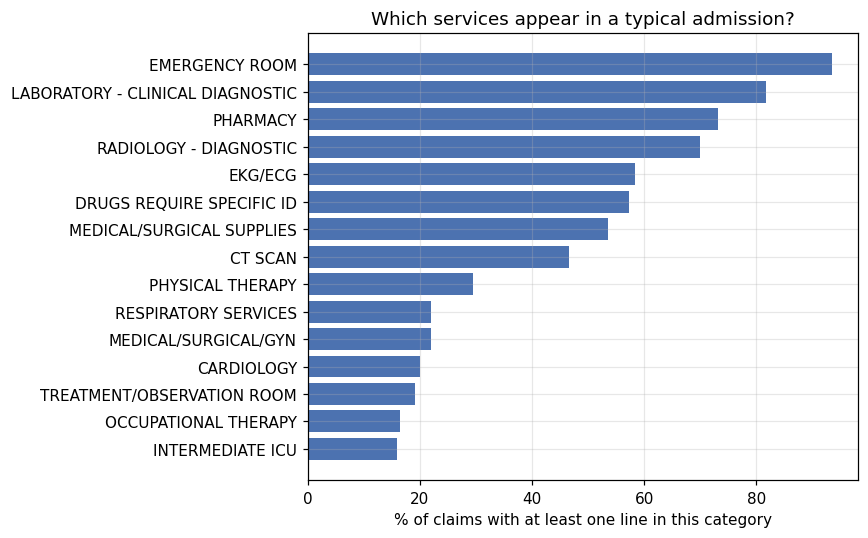

In [59]:
fig, ax = plt.subplots(figsize=(8, 5))

top_density = density.head(15).sort_values()
ax.barh([c[:32] for c in top_density.index], top_density.values * 100, color='#4C72B0')
ax.set_xlabel('% of claims with at least one line in this category')
ax.set_title('Which services appear in a typical admission?')
plt.tight_layout()
plt.show()

In [60]:
# Documented decision: absence of a billed line means zero spend on that service.
wide_cost0 = wide_cost.fillna(0)

wide_cost0.iloc[:6, :6]

ServiceCategory,ADMISSION CHARGE,ANESTHESIA,BLOOD,BLOOD STORAGE/PROCESSING,CARDIOLOGY,CLINIC
MedicalClaim,,,,,,
0012a8eb3c2be5f5,0.0,0.0,0.0,0.0,0.0,0.0
002fd7d73d8060f1,0.0,0.0,0.0,0.0,"2,310.6",0.0
003886fc8ec986d4,0.0,0.0,0.0,0.0,0.0,0.0
004fa1cd47f65193,0.0,0.0,0.0,0.0,0.0,0.0
005edafb00d0f6eb,0.0,0.0,0.0,0.0,0.0,0.0
00667b58e8ae902b,0.0,0.0,0.0,0.0,0.0,0.0




## 5. Reattach the claim-level attributes

The wide frame currently holds only measurements. The patient and episode attributes were dropped by the pivot because they were not in `index`, `columns`, or `values`.

Because we proved in section 1 that those attributes are **constant within a claim**, we can recover them safely with `first`. That earlier diagnostic was not an academic exercise - it is what licenses this step.

In [61]:
claim_attrs = (claims
               .groupby('MedicalClaim')
               .agg(Hospital      = ('HospitalName', 'first'),
                    EncounterType = ('TypeFlag', 'first'),
                    Diagnosis     = ('PrincipalDiagnosisDesc', 'first'),
                    DxCode        = ('PrincipalDiagnosis', 'first'),
                    Admission     = ('StartDate', 'first'),
                    LengthOfStay  = ('LengthOfStay', 'first'),
                    Age           = ('AgeAtAdmission', 'first'),
                    BilledLines   = ('ClaimItem', 'size'),
                    TotalCost     = ('TotalExpenses', 'sum')))

claim_attrs.head()

,Hospital,EncounterType,Diagnosis,DxCode,Admission,LengthOfStay,Age,BilledLines,TotalCost
MedicalClaim,,,,,,,,,
0012a8eb3c2be5f5,ae2f2d9e,ER,Strain of right Achilles,S86.011A,2020-11-18,0,64,4,"4,668.7"
002fd7d73d8060f1,cf2a3695,INP,Trigeminal neuralgia,G50.0,2020-07-17,6,75,24,"53,501.3"
003886fc8ec986d4,b592f5ae,ER,Acute bronchitis unspecif,J20.9,2020-02-26,0,64,18,"17,115.7"
004fa1cd47f65193,4d103af0,ER,Zoster without complicati,B02.9,2020-09-06,0,69,9,"3,672.4"
005edafb00d0f6eb,a9bf1474,ER,Pain in left foot,M79.672,2020-03-06,0,73,3,"2,548.7"


In [62]:
wide = claim_attrs.join(wide_cost0)

print(f'analysis-ready wide frame: {wide.shape[0]:,} claims x {wide.shape[1]} columns')
wide.head()

analysis-ready wide frame: 3,361 claims x 74 columns


,Hospital,EncounterType,Diagnosis,DxCode,Admission,LengthOfStay,Age,BilledLines,TotalCost,ADMISSION CHARGE,ANESTHESIA,BLOOD,BLOOD STORAGE/PROCESSING,CARDIOLOGY,CLINIC,CORONARY CARE,CT SCAN,DIAGNOSTIC RADIOPHARMS,DRUGS REQUIRE SPECIFIC ID,EEG,...,PHARMACY,PHYSICAL THERAPY,PREVENTIVE CARE SERVICES,PSYCHIATRIC,PSYCHIATRIC/PSYCHOLOGICAL SVCS,PSYCHIATRIC/PSYCHOLOGICAL TRT,PULMONARY FUNCTION,RADIOLOGY - DIAGNOSTIC,RADIOLOGY - THERAPEUTIC,RECOVERY ROOM,REHAB,RESPIRATORY SERVICES,ROOM & BOARD (PRIVATE),ROOM & BOARD (SEMI-PRIVATE 2 BEDS),SPEECH-LANGUAGE PATHOLOGY,STERILE ENVIRONMENT,SURGICAL,TRAUMA,TRAUMA RESPONSE,TREATMENT/OBSERVATION ROOM
MedicalClaim,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0012a8eb3c2be5f5,ae2f2d9e,ER,Strain of right Achilles,S86.011A,2020-11-18,0,64,4,"4,668.7",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,"1,059.7",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
002fd7d73d8060f1,cf2a3695,INP,Trigeminal neuralgia,G50.0,2020-07-17,6,75,24,"53,501.3",0.0,0.0,0.0,0.0,"2,310.6",0.0,0.0,"9,426.4",0.0,0.0,0.0,...,"3,308.4","1,259.5",0.0,0.0,0.0,0.0,514.6,0.0,0.0,0.0,0.0,"2,087.2",0.0,0.0,"1,098.8",0.0,"4,186.0",0.0,0.0,0.0
003886fc8ec986d4,b592f5ae,ER,Acute bronchitis unspecif,J20.9,2020-02-26,0,64,18,"17,115.7",0.0,0.0,0.0,0.0,0.0,0.0,0.0,"6,985.8",0.0,521.6,0.0,...,764.5,0.0,0.0,0.0,0.0,0.0,47.1,477.5,0.0,0.0,0.0,337.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
004fa1cd47f65193,4d103af0,ER,Zoster without complicati,B02.9,2020-09-06,0,69,9,"3,672.4",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113.5,0.0,...,113.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
005edafb00d0f6eb,a9bf1474,ER,Pain in left foot,M79.672,2020-03-06,0,73,3,"2,548.7",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.6,0.0,0.0,0.0,0.0,0.0,0.0,983.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


This is now a classic **feature matrix**: one observation per row, one feature per column. It is the shape scikit-learn expects, the shape a correlation matrix expects, and the shape most plotting functions expect. Everything downstream gets easier.

---

## 7. Operations that are natural in wide format

### 7a. Row-wise arithmetic

In long format, "what fraction of this admission went on pharmacy?" needs a groupby plus a merge. In wide format it is one division.

In [63]:
service_cols = list(wide_cost0.columns)

wide_share = wide_cost0.div(wide_cost0.sum(axis=1), axis=0)

# sanity check: every row must sum to 1
assert np.allclose(wide_share.sum(axis=1), 1.0)
print('every claim composition sums to 100%\n')

wide_share.mean().sort_values(ascending=False).head(10).to_frame('mean share of claim cost')

every claim composition sums to 100%



,mean share of claim cost
ServiceCategory,
EMERGENCY ROOM,0.3
LABORATORY - CLINICAL DIAGNOSTIC,0.2
CT SCAN,0.2
RADIOLOGY - DIAGNOSTIC,0.1
OPERATING ROOM SERVICES,0.0
CARDIOLOGY,0.0
PHARMACY,0.0
DRUGS REQUIRE SPECIFIC ID,0.0
MEDICAL/SURGICAL/GYN,0.0


> **A subtlety worth raising with students.** There are two different "average shares" here and they answer different questions:
>
> - **Mean of shares** (above) - averages each claim equally. *What does a typical admission look like?*
> - **Share of the totals** (below) - weights by claim size. *Where does the money actually go?*
>
> Expensive surgical admissions dominate the second and are just one row in the first. Reporting the wrong one is a common and consequential error.

In [64]:
comparison = pd.DataFrame({
    'mean of per-claim shares': wide_share.mean(),
    'share of total spend'    : wide_cost0.sum() / wide_cost0.to_numpy().sum(),
})

(comparison
 .sort_values('share of total spend', ascending=False)
 .head(12)
 .style.format('{:.1%}'))

,mean of per-claim shares,share of total spend
ServiceCategory,,
LABORATORY - CLINICAL DIAGNOSTIC,16.9%,15.9%
CT SCAN,16.2%,13.4%
OPERATING ROOM SERVICES,3.6%,10.8%
EMERGENCY ROOM,27.0%,6.7%
CARDIOLOGY,3.0%,5.9%
MEDICAL/SURGICAL SUPPLIES,2.0%,5.5%
PHARMACY,3.0%,5.1%
DRUGS REQUIRE SPECIFIC ID,2.7%,4.2%
MEDICAL/SURGICAL/GYN,2.4%,3.7%


### 7b. Column-wise statistics and correlation

A correlation matrix requires variables to be **columns**. In long format this is simply not computable without reshaping first - which is a good argument for why the wide form exists at all.

A positive correlation between two service lines means they tend to be expensive on the same admissions: they are clinically bundled.

In [65]:
top_services = (wide_cost0.sum()
                .sort_values(ascending=False)
                .head(12).index.tolist())

corr = wide_cost0[top_services].corr()

corr.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1).format('{:.2f}')

ServiceCategory,LABORATORY - CLINICAL DIAGNOSTIC,CT SCAN,OPERATING ROOM SERVICES,EMERGENCY ROOM,CARDIOLOGY,MEDICAL/SURGICAL SUPPLIES,PHARMACY,DRUGS REQUIRE SPECIFIC ID,MEDICAL/SURGICAL/GYN,INTERMEDIATE ICU,ANESTHESIA,RADIOLOGY - DIAGNOSTIC
ServiceCategory,,,,,,,,,,,,
LABORATORY - CLINICAL DIAGNOSTIC,1.00,0.35,0.27,0.18,0.18,0.28,0.42,0.52,0.29,0.35,0.21,0.65
CT SCAN,0.35,1.00,0.03,0.31,0.02,0.03,0.09,0.17,0.19,0.11,0.04,0.27
OPERATING ROOM SERVICES,0.27,0.03,1.00,-0.13,0.03,0.56,0.21,0.18,0.17,0.14,0.67,0.29
EMERGENCY ROOM,0.18,0.31,-0.13,1.00,0.08,-0.13,0.04,0.05,0.11,0.10,-0.08,0.11
CARDIOLOGY,0.18,0.02,0.03,0.08,1.00,0.18,0.04,0.11,0.07,0.13,0.05,0.08
MEDICAL/SURGICAL SUPPLIES,0.28,0.03,0.56,-0.13,0.18,1.00,0.28,0.21,0.13,0.15,0.47,0.43
PHARMACY,0.42,0.09,0.21,0.04,0.04,0.28,1.00,0.29,0.09,0.45,0.19,0.30
DRUGS REQUIRE SPECIFIC ID,0.52,0.17,0.18,0.05,0.11,0.21,0.29,1.00,0.17,0.25,0.16,0.40
MEDICAL/SURGICAL/GYN,0.29,0.19,0.17,0.11,0.07,0.13,0.09,0.17,1.00,0.06,0.12,0.18


In [66]:
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack()
             .sort_values(ascending=False))

print('Most co-occurring service lines (cost moves together):')
print(pairs.head(5).to_string())
print('\nMost substitutive (one instead of the other):')
print(pairs.tail(5).to_string())

Most co-occurring service lines (cost moves together):
ServiceCategory                   ServiceCategory          
OPERATING ROOM SERVICES           ANESTHESIA                  0.7
LABORATORY - CLINICAL DIAGNOSTIC  RADIOLOGY - DIAGNOSTIC      0.6
OPERATING ROOM SERVICES           MEDICAL/SURGICAL SUPPLIES   0.6
LABORATORY - CLINICAL DIAGNOSTIC  DRUGS REQUIRE SPECIFIC ID   0.5
MEDICAL/SURGICAL SUPPLIES         ANESTHESIA                  0.5

Most substitutive (one instead of the other):
ServiceCategory          ServiceCategory          
OPERATING ROOM SERVICES  CARDIOLOGY                   0.0
CT SCAN                  CARDIOLOGY                   0.0
EMERGENCY ROOM           ANESTHESIA                  -0.1
                         MEDICAL/SURGICAL SUPPLIES   -0.1
OPERATING ROOM SERVICES  EMERGENCY ROOM              -0.1


---

## 8. Visualisations that need the wide format

### 8a. Cost composition by encounter type - stacked bars

A stacked bar chart is *inherently* a wide-format plot: each segment of the bar is a column.

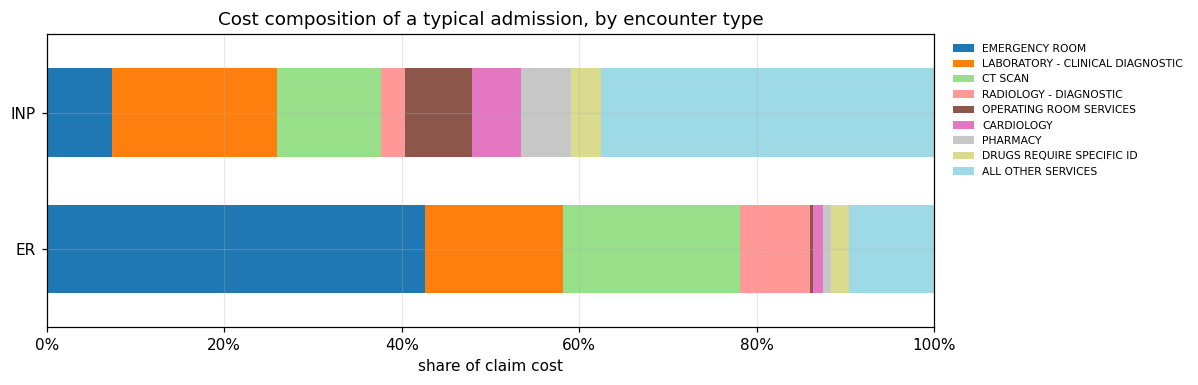

In [67]:
composition = (wide_share
               .join(claim_attrs['EncounterType'])
               .groupby('EncounterType')[service_cols]
               .mean())

plot_cols = composition.mean().sort_values(ascending=False).head(8).index.tolist()
plot_df = composition[plot_cols].copy()
plot_df['ALL OTHER SERVICES'] = 1 - plot_df.sum(axis=1)

ax = plot_df.plot(kind='barh', stacked=True, figsize=(11, 3.6),
                  colormap='tab20', width=0.65)
ax.set_xlabel('share of claim cost')
ax.set_ylabel('')
ax.set_title('Cost composition of a typical admission, by encounter type')
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

Inpatient and emergency admissions have visibly different cost anatomies. That comparison is one line of code on a wide frame and genuinely awkward on a long one.



### 8c. Claim-level cost heatmap

Each row is an admission, each column a service line. Patterns of care become visually obvious - and note the log scale, without which a single surgical charge would flatten everything else to invisibility.

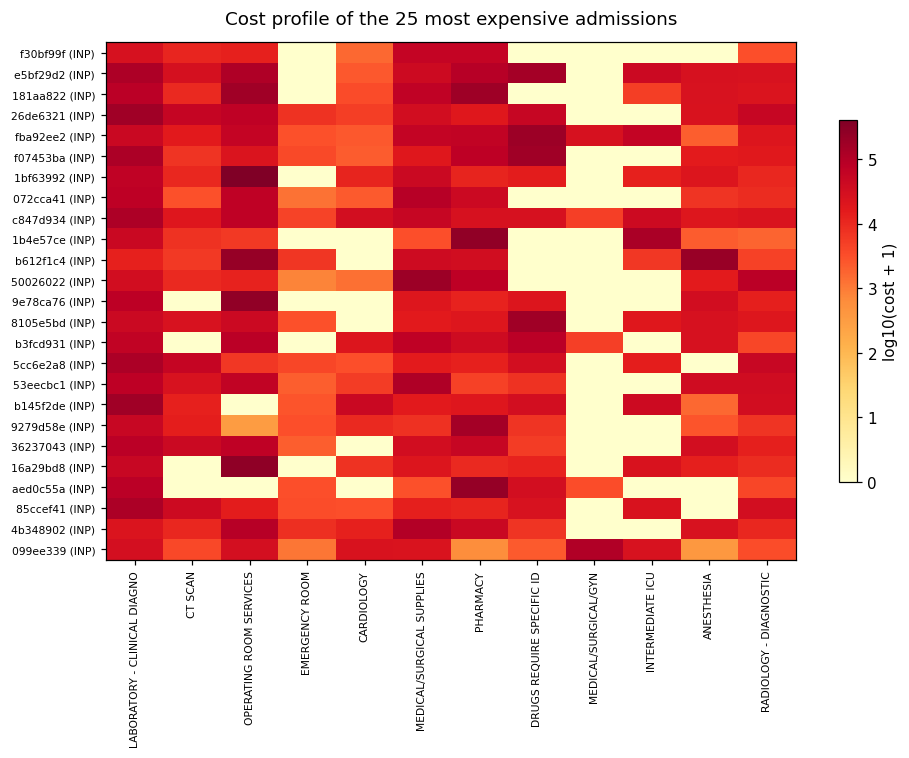

In [68]:
sample = wide_cost0.loc[claim_attrs['TotalCost'].nlargest(25).index, top_services]
encounter = claim_attrs.loc[sample.index, 'EncounterType']

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(np.log10(sample.values + 1), cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(top_services)))
ax.set_xticklabels([c[:28] for c in top_services], rotation=90, fontsize=7)
ax.set_yticks(range(len(sample)))
ax.set_yticklabels([f'{i[:8]} ({t})' for i, t in zip(sample.index, encounter)],
                   fontsize=7)
ax.grid(False)

fig.colorbar(im, ax=ax, shrink=0.7, label='log10(cost + 1)')
ax.set_title('Cost profile of the 25 most expensive admissions', pad=12)
plt.tight_layout()
plt.show()

---

## 9. A second reshape: diagnosis x hospital

The first pivot treated the *claim* as the entity. But "wide" is not a property of a dataset - it is a property of a dataset **relative to a chosen entity**. Change the entity and you get a completely different wide frame from the very same source.

Here the question is a benchmarking one: **does the same condition cost the same at every hospital?**

### The trap

The obvious move is to pivot `claims` directly. **That would be wrong.** Averaging `TotalExpenses` over the long frame averages *billed lines*, not admissions - so a claim with 25 lines would count 25 times against one with 4.

We must aggregate to claim level first. `claim_attrs` already is claim level, so we pivot that.

In [69]:
claim_level = claim_attrs.reset_index()

# WRONG - pivots the LINE-level frame, so it averages billed lines
by_line = (claims
           .pivot_table(index='PrincipalDiagnosisDesc',
                        values='TotalExpenses', aggfunc='mean')
           .rename(columns={'TotalExpenses': 'mean per billed LINE (wrong)'})
           .rename_axis('Diagnosis'))

# RIGHT - pivots the CLAIM-level frame, so it averages admissions
by_claim = (claim_level
            .pivot_table(index='Diagnosis',
                         values='TotalCost', aggfunc='mean')
            .rename(columns={'TotalCost': 'mean per ADMISSION (right)'}))

check = (by_line.join(by_claim, how='inner')
                .sort_values('mean per ADMISSION (right)', ascending=False))

print('Not even proportional to each other - the ranking itself changes:\n')
check.head(10)

Not even proportional to each other - the ranking itself changes:



,mean per billed LINE (wrong),mean per ADMISSION (right)
Diagnosis,,
Pyothorax with fistula,"21,963.4","856,572.7"
Unspecified trochanteric,"19,568.3","684,891.8"
Acute lymphoblastic leuke,"18,140.6","616,781.7"
Unspecified injury of bra,"14,806.7","473,816.0"
Rheumatic disorders of bo,"15,022.1","465,684.5"
Pneumonia due to Methicil,"11,956.4","454,344.1"
Dissection of thoracic ao,"12,262.5","392,399.7"
Thoracic aortic aneurysm,"12,159.7","316,151.2"
Benign neoplasm of pituit,"10,333.9","315,183.3"


In [70]:
top_dx = claim_level['Diagnosis'].value_counts().head(10).index.tolist()

dx_by_hospital = (claim_level[claim_level['Diagnosis'].isin(top_dx)]
                  .pivot_table(index='Diagnosis',
                               columns='Hospital',
                               values='TotalCost',
                               aggfunc='mean',
                               margins=True,
                               margins_name='ALL HOSPITALS'))

dx_by_hospital.round(0)

Hospital,03840bce,04b77561,13dda4ec,1c8e7f9c,2148dc02,21c2e90b,226eab93,22781f18,295f5b41,2c2f104d,2f45157f,30807d03,34a13e9b,34c811a7,3562d906,35da0521,3b3d689b,4322635e,446442f4,46658edc,...,bfb63c44,ce1c92b6,cf2a3695,d075a201,d0fdd2e6,d16d724d,d9184f61,db3c8b2f,db571453,e07b4c04,e1674de3,f07b928c,f0b2e1c6,f120aa2d,fa9fff54,fb3d8b96,fc72a0b8,fdc65fe8,ffbe51b1,ALL HOSPITALS
Diagnosis,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Acute kidney failure unsp,NaN,"83,757.0",NaN,NaN,NaN,"51,534.0",NaN,"24,397.0","44,930.0","9,815.0","91,250.0",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"62,794.0",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"79,571.0",NaN,NaN,NaN,"27,433.0","44,255.0",NaN,NaN,NaN,NaN,NaN,NaN,"52,260.0"
COVID-19,"19,954.0","63,298.0",NaN,NaN,"44,519.0",NaN,NaN,NaN,"73,033.0",NaN,"22,400.0",NaN,NaN,NaN,NaN,"239,951.0",NaN,NaN,"112,717.0",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"6,881.0",NaN,NaN,"29,786.0",NaN,NaN,NaN,NaN,"7,131.0",NaN,NaN,NaN,NaN,"53,287.0"
Chronic obstructive pulmo,NaN,"12,792.0",NaN,"3,420.0","14,694.0",NaN,NaN,"25,222.0","13,271.0",NaN,"17,820.0","27,178.0",NaN,"59,856.0",NaN,NaN,"52,898.0",NaN,"25,514.0","33,656.0",...,NaN,NaN,"65,690.0",NaN,NaN,NaN,"8,774.0","48,855.0",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"26,276.0",NaN,NaN,"7,781.0","22,763.0"
Hypertensive heart and ch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"51,908.0",NaN,NaN,"38,294.0",NaN,NaN,NaN,"100,774.0",NaN,NaN,"80,236.0","30,676.0",...,"33,247.0",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"22,813.0",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"63,429.0"
Hypertensive heart diseas,NaN,NaN,NaN,NaN,"23,753.0",NaN,NaN,"159,963.0","27,679.0",NaN,"14,058.0",NaN,NaN,NaN,NaN,NaN,NaN,"78,642.0","52,839.0",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"34,835.0",NaN,NaN,NaN,NaN,NaN,"27,258.0",NaN,NaN,NaN,"56,380.0"
Laceration without foreig,NaN,NaN,NaN,NaN,"4,165.0",NaN,NaN,"2,286.0","3,020.0",NaN,"9,587.0",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"21,490.0","21,267.0",...,NaN,NaN,NaN,"4,732.0",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,669.0",731.0,NaN,NaN,"13,707.0"
Other chest pain,NaN,"19,146.0","35,285.0",NaN,"10,183.0","11,264.0",NaN,NaN,"22,760.0",NaN,"62,211.0",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"28,064.0","21,827.0",...,NaN,"2,956.0",NaN,NaN,NaN,NaN,"32,593.0","57,322.0",NaN,"97,029.0",NaN,"13,174.0",NaN,"5,452.0",NaN,"14,481.0",NaN,NaN,NaN,"25,018.0"
Sepsis unspecified organi,NaN,"81,713.0",NaN,NaN,"48,214.0",NaN,"15,789.0","172,926.0","137,911.0",NaN,"633,034.0",NaN,NaN,NaN,"30,694.0","108,237.0",NaN,NaN,"91,235.0","59,992.0",...,NaN,NaN,"185,419.0","38,946.0",NaN,NaN,NaN,NaN,NaN,"26,737.0","107,683.0",NaN,"54,403.0",NaN,NaN,"26,542.0",NaN,NaN,NaN,"106,649.0"
Type 2 diabetes mellitus,NaN,NaN,NaN,NaN,NaN,"49,099.0",NaN,NaN,"66,093.0",NaN,"8,834.0",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"69,093.0",NaN,...,NaN,NaN,NaN,NaN,NaN,"19,190.0",NaN,"21,905.0","391,014.0",NaN,NaN,NaN,"13,169.0",NaN,NaN,NaN,NaN,NaN,NaN,"59,203.0"


> **On `margins=True`.** It appends row and column totals computed from the *underlying data*, not by averaging the cells. For `aggfunc='sum'` those coincide; for `'mean'` they do not, because the margin is correctly weighted by volume. Students frequently try to reproduce a margin by averaging a row and get confused when it does not match. This is why.

Also note the `NaN`s: not every hospital treats every condition. **Here `NaN` genuinely means "no data", not zero** - the opposite of section 4. Filling these with `0` would claim a hospital treats stroke for free.

### Volume alongside cost

A cost difference on 2 admissions is noise; on 200 it is a finding. Always pair a cost pivot with a count pivot.

In [71]:
dx_volume = (claim_level[claim_level['Diagnosis'].isin(top_dx)]
             .pivot_table(index='Diagnosis', columns='Hospital',
                          values='TotalCost', aggfunc='size'))

dx_volume.fillna(0).astype(int)

Hospital,03840bce,04b77561,13dda4ec,1c8e7f9c,2148dc02,21c2e90b,226eab93,22781f18,295f5b41,2c2f104d,2f45157f,30807d03,34a13e9b,34c811a7,3562d906,35da0521,3b3d689b,4322635e,446442f4,46658edc,...,bb6ef784,bfb63c44,ce1c92b6,cf2a3695,d075a201,d0fdd2e6,d16d724d,d9184f61,db3c8b2f,db571453,e07b4c04,e1674de3,f07b928c,f0b2e1c6,f120aa2d,fa9fff54,fb3d8b96,fc72a0b8,fdc65fe8,ffbe51b1
Diagnosis,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Acute kidney failure unsp,0,2,0,0,0,1,0,2,2,1,1,0,0,0,0,0,0,0,4,0,...,0,0,0,0,0,0,0,0,3,0,0,0,2,2,0,0,0,0,0,0
COVID-19,1,3,0,0,9,0,0,0,4,0,1,0,0,0,0,1,0,0,4,0,...,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0
Chronic obstructive pulmo,0,1,0,1,3,0,0,1,1,0,4,1,0,1,0,0,1,0,7,1,...,2,0,0,1,0,0,0,2,1,0,0,0,0,0,0,0,1,0,0,1
Hypertensive heart and ch,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,11,3,...,0,1,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0
Hypertensive heart diseas,0,0,0,0,1,0,0,1,4,0,1,0,0,0,0,0,0,1,9,0,...,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0
Laceration without foreig,0,0,0,0,2,0,0,1,3,0,3,0,0,0,0,0,0,0,5,1,...,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0
Other chest pain,0,2,1,0,10,3,0,0,9,0,5,0,0,0,0,0,0,0,10,3,...,0,0,1,0,0,0,0,1,1,0,1,0,1,0,1,0,2,0,0,0
Sepsis unspecified organi,0,2,0,0,2,0,1,1,3,0,1,0,0,0,1,2,0,0,26,2,...,1,0,0,2,1,0,0,0,0,0,1,1,0,1,0,0,2,0,0,0
Type 2 diabetes mellitus,0,0,0,0,0,2,0,0,4,0,1,0,0,0,0,0,0,0,14,0,...,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0


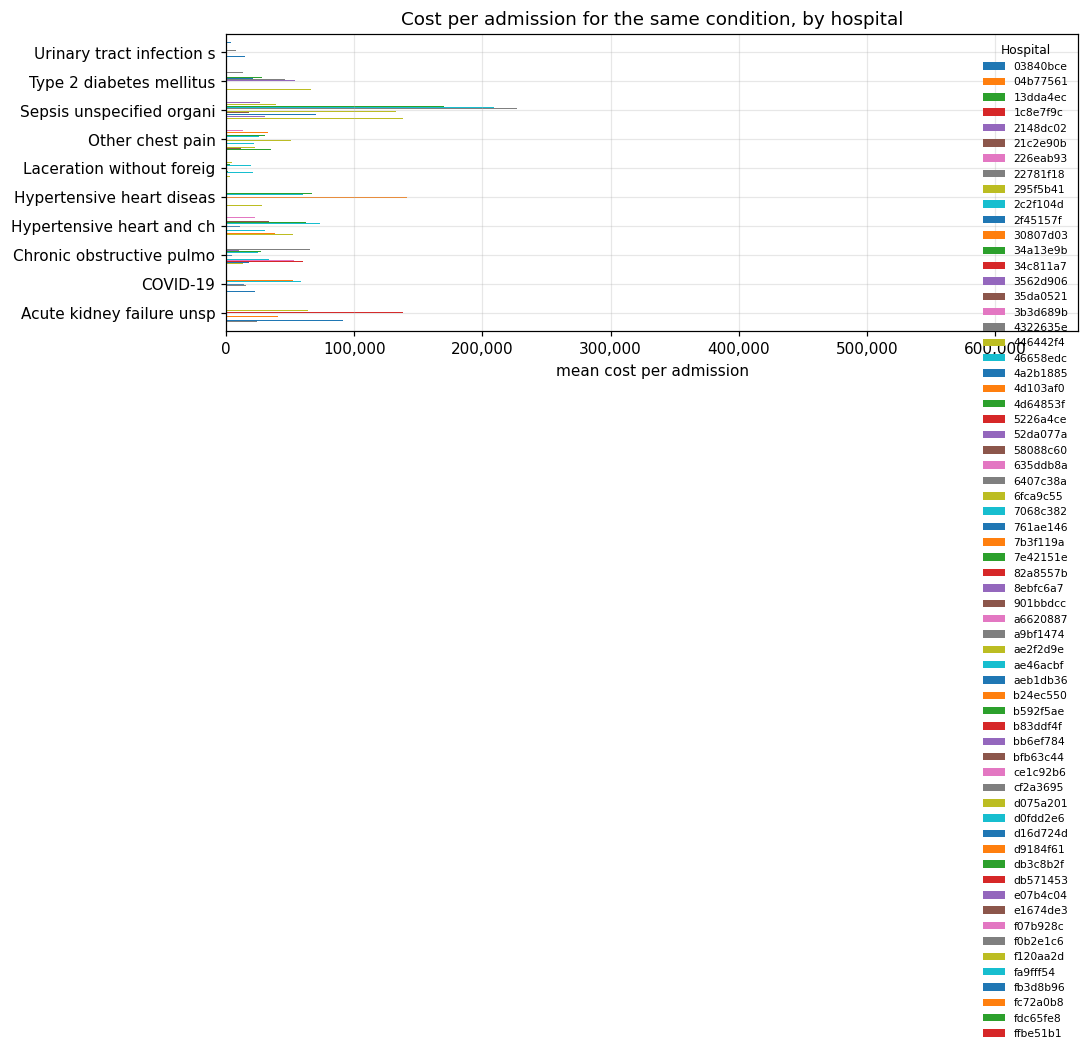

In [72]:
plot_data = dx_by_hospital.drop(index='ALL HOSPITALS', columns='ALL HOSPITALS')

ax = plot_data.plot(kind='barh', figsize=(10, 7), width=0.78)
ax.set_xlabel('mean cost per admission')
ax.set_ylabel('')
ax.set_title('Cost per admission for the same condition, by hospital')
ax.xaxis.set_major_formatter(lambda v, _: f'{v:,.0f}')
ax.legend(title='Hospital', fontsize=7, title_fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

### Indexed heatmap

Raw costs are hard to compare across conditions - a cardiac admission costs more than a UTI everywhere, which tells us nothing about the hospitals. Dividing each row by its own mean removes the condition effect and isolates the **hospital effect**. Values above 1 mean "more expensive than typical for this condition".

This normalise-within-row move is a standard benchmarking technique, and it is trivial once the data is wide.

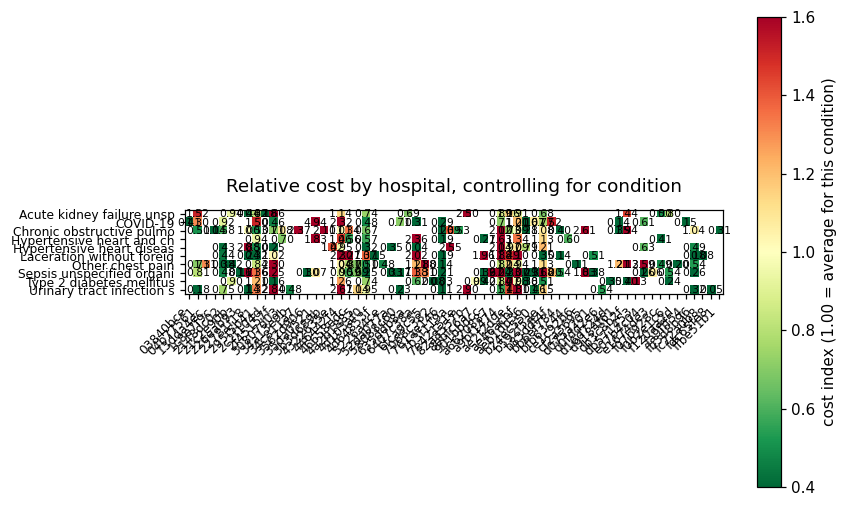

In [73]:
indexed = plot_data.div(plot_data.mean(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(indexed.values, cmap='RdYlGn_r', vmin=0.4, vmax=1.6)

ax.set_xticks(range(indexed.shape[1]))
ax.set_xticklabels(indexed.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(indexed.shape[0]))
ax.set_yticklabels([d[:34] for d in indexed.index], fontsize=8)
ax.grid(False)

for i in range(indexed.shape[0]):
    for j in range(indexed.shape[1]):
        v = indexed.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7)

fig.colorbar(im, ax=ax, shrink=0.75,
             label='cost index (1.00 = average for this condition)')
ax.set_title('Relative cost by hospital, controlling for condition', pad=12)
plt.tight_layout()
plt.show()

> **Interpretation warning to give students explicitly.** A high index is *not* evidence of inefficiency. It could equally reflect a sicker case mix, a tertiary referral role, or a longer average stay. Check `dx_volume` before saying anything, and treat cells backed by a handful of admissions as unreadable. This is the point where a reshaping exercise becomes a claim about the real world, and where the statistical care has to start.

---

## 10. The round trip: `melt`

`melt` is the inverse of `pivot`. Going wide is for analysis; going long is for storage, for databases, and for plotting libraries such as seaborn and plotnine that expect tidy input.

In [74]:
back_to_long = (wide_cost              # note: the version WITH NaNs
                .reset_index()
                .melt(id_vars='MedicalClaim',
                      var_name='ServiceCategory',
                      value_name='TotalExpenses')
                .dropna(subset=['TotalExpenses'])
                .sort_values(['MedicalClaim', 'ServiceCategory'])
                .reset_index(drop=True))

n_pairs = claims.groupby(['MedicalClaim', 'ServiceCategory']).ngroups

print(f'original long frame       : {len(claims):,} rows')
print(f'after pivot then melt     : {len(back_to_long):,} rows')
print(f'distinct claim x category : {n_pairs:,} rows')

back_to_long.head()

original long frame       : 52,563 rows
after pivot then melt     : 28,190 rows
distinct claim x category : 28,190 rows


,MedicalClaim,ServiceCategory,TotalExpenses
0,0012a8eb3c2be5f5,EKG/ECG,678.0
1,0012a8eb3c2be5f5,EMERGENCY ROOM,"2,926.0"
2,0012a8eb3c2be5f5,PHARMACY,5.0
3,0012a8eb3c2be5f5,RADIOLOGY - DIAGNOSTIC,"1,059.7"
4,002fd7d73d8060f1,CARDIOLOGY,"2,310.6"


### The round trip is not lossless - and that is the lesson

We do not get our original row count back. We get the number of distinct claim-category pairs.

The `aggfunc='sum'` **destroyed information permanently**: five separate pharmacy lines became one number, and no inverse operation can recover them. The individual `ClaimItem` numbers, `RevenueCode` detail, and the line-level `Id` are gone for good.

> **Rule to give students: aggregate late.** Keep the long, line-level file as your source of truth and treat every wide frame as a disposable, purpose-built view. If you overwrite your long data with a pivoted version, you have thrown away detail you cannot rebuild.

If you melt the `fillna(0)` version instead, you get something worse - a fully dense frame of mostly fabricated zero rows.

In [75]:
dense_melt = (wide_cost0.reset_index()
              .melt(id_vars='MedicalClaim',
                    var_name='ServiceCategory',
                    value_name='TotalExpenses'))

is_zero = dense_melt['TotalExpenses'] == 0

print(f'melting the fillna(0) frame : {len(dense_melt):,} rows')
print(f'of which are invented zeros : {is_zero.sum():,} ({is_zero.mean():.0%})')

melting the fillna(0) frame : 218,465 rows
of which are invented zeros : 190,291 (87%)


---

## 11. Summary

| | Long format | Wide format |
|---|---|---|
| **Row means** | one measurement | one entity |
| **Adding a variable** | append rows | add a column |
| **Sparsity** | absent rows, compact | explicit `NaN`, sparse |
| **Good for** | storage, ETL, tidy plotting | modelling, correlation, heatmaps, row arithmetic |
| **pandas verb** | `melt`, `stack` | `pivot`, `pivot_table`, `unstack` |

**Six things to remember**

1. Prove the format with a within-entity variation check; do not eyeball it.
2. `pivot` reshapes, `pivot_table` reshapes **and aggregates**. Duplicates force the second.
3. `NaN` after a pivot usually means *never occurred*, but decide case by case before filling.
4. Always reconcile totals after a reshape.
5. Aggregate to the right entity **before** pivoting, or you will average the wrong thing.
6. Aggregation is irreversible. Keep the long file.

---
